# Лабораторная работа 02

## Базовый конвейер анализа данных в Pandas

**ФИО:** Аюпова В.Р.
**Группа:** ЕТ-212
**Дата:** 25.09.2026

## 3. Формирование и сохранение исходных данных

### Задание 3.1

In [1]:
import numpy as np
import pandas as pd

In [2]:
raw_data = {
    "order_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015
    ],
    "channel": [
        "site", "app", "app", "marketplace", "site",
        "app", "site", "marketplace", "app", "site",
        "marketplace", "app", "site", "site", "marketplace"
    ],
    "order_sum": [
        1200, 2500, 1800, 3200, 900,
        1500, 2800, 45000, 2100, 1700,
        3600, 1100, 2400, 1900, 3300
    ],
    "delivery_time": [
        25, np.nan, 40, 55, 20,
        30, np.nan, 70, 35, 45,
        50, 18, 27, np.nan, 60
    ],
    "rating": [
        5, 4, 5, 3, 5,
        4, 2, 1, 5, 4,
        3, 5, 4, 5, 2
    ]
}

In [3]:
df = pd.DataFrame(raw_data)
print(df)

    order_id      channel  order_sum  delivery_time  rating
0       1001         site       1200           25.0       5
1       1002          app       2500            NaN       4
2       1003          app       1800           40.0       5
3       1004  marketplace       3200           55.0       3
4       1005         site        900           20.0       5
5       1006          app       1500           30.0       4
6       1007         site       2800            NaN       2
7       1008  marketplace      45000           70.0       1
8       1009          app       2100           35.0       5
9       1010         site       1700           45.0       4
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2


In [4]:
df.to_csv("online_store_orders.csv", index=False)

### Контрольный вопрос

**Для чего используется параметр `index=False`?**

Параметр `index=False` указывает Pandas не сохранять индекс строки (0, 1, 2, ...) 
в CSV-файл. Если его не указать, при сохранении добавится дополнительный первый 
столбец с индексами, и при повторной загрузке через `pd.read_csv()` появится 
лишний столбец `Unnamed: 0`, что исказит структуру таблицы.

## 4. Загрузка и первичный анализ данных

### Задание 4.1

In [5]:
store_df = pd.read_csv("online_store_orders.csv")

In [6]:
print("Первые 5 строк:")
print(store_df.head())

Первые 5 строк:
   order_id      channel  order_sum  delivery_time  rating
0      1001         site       1200           25.0       5
1      1002          app       2500            NaN       4
2      1003          app       1800           40.0       5
3      1004  marketplace       3200           55.0       3
4      1005         site        900           20.0       5


In [7]:
print("\nПоследние 5 строк:")
print(store_df.tail())


Последние 5 строк:
    order_id      channel  order_sum  delivery_time  rating
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2


In [8]:
print("\nРазмер таблицы:")
print(store_df.shape)


Размер таблицы:
(15, 5)


In [9]:
print("\nНазвания столбцов:")
print(store_df.columns)


Названия столбцов:
Index(['order_id', 'channel', 'order_sum', 'delivery_time', 'rating'], dtype='object')


In [10]:
print("\nИнформация о таблице:")
print(store_df.info())


Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       15 non-null     int64  
 1   channel        15 non-null     object 
 2   order_sum      15 non-null     int64  
 3   delivery_time  12 non-null     float64
 4   rating         15 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 732.0+ bytes
None


### Контрольные вопросы

1. **Количество строк:** 15
2. **Количество столбцов:** 5
3. **Числовые столбцы:** `order_id`, `order_sum`, `delivery_time`, `rating`
4. **Столбцы с пропущенными значениями:** `delivery_time`
5. **Количество пропущенных значений:** 3

## 5. Выборка и фильтрация данных

### 5.1. Выбор столбцов

In [11]:
store_df[["order_sum", "delivery_time"]]

,order_sum,delivery_time
0,1200,25.0
1,2500,NaN
2,1800,40.0
3,3200,55.0
4,900,20.0
5,1500,30.0
6,2800,NaN
7,45000,70.0
8,2100,35.0
9,1700,45.0


### 5.2. Выбор строк

Получим строки с индексами от 3 до 7 включительно и столбцы `order_sum`, `delivery_time`.

In [12]:
slice_df = store_df.iloc[3:8][["order_sum", "delivery_time"]]
print(slice_df)

   order_sum  delivery_time
3       3200           55.0
4        900           20.0
5       1500           30.0
6       2800            NaN
7      45000           70.0


### 5.3. Фильтрация

Заказы, у которых одновременно:
- сумма больше 2000 руб.;
- рейтинг равен 5.

In [13]:
premium_orders = store_df[(store_df["order_sum"] > 2000) & (store_df["rating"] == 5)]
print(premium_orders)

   order_id channel  order_sum  delivery_time  rating
8      1009     app       2100           35.0       5


### Контрольный вопрос

**Почему используется `&`, а не `and`?**

`&` — это векторизованная логическая операция Pandas/NumPy. Она работает 
поэлементно со всей Series и возвращает булеву маску. `and` — встроенный 
оператор Python, работает только со скалярными значениями и вызовет ошибку 
`ValueError: The truth value of a Series is ambiguous`. Для объединения 
условий в Pandas используются `&` (И), `|` (ИЛИ), `~` (НЕ), 
а каждое условие берётся в скобки.

## 6. Проверка качества данных и статистический анализ

### 6.1. Пропущенные значения

Определим количество пропущенных значений в каждом столбце.

In [14]:
store_df.isna().sum()

order_id         0
channel          0
order_sum        0
delivery_time    3
rating           0
dtype: int64

**Сколько заказов не имеют информации о времени доставки?**

3 заказа — пропуски в столбце `delivery_time`.

### 6.2. Описательная статистика

Получим описательную статистику числовых столбцов.

In [15]:
store_df.describe()

,order_id,order_sum,delivery_time,rating
count,15.000000,15.00000,12.000000,15.000000
mean,1008.000000,5000.00000,39.583333,3.800000
std,4.472136,11096.33144,16.654010,1.320173
min,1001.000000,900.00000,18.000000,1.000000
25%,1004.500000,1600.00000,26.500000,3.000000
50%,1008.000000,2100.00000,37.500000,4.000000
75%,1011.500000,3000.00000,51.250000,5.000000
max,1015.000000,45000.00000,70.000000,5.000000


**Анализ описательной статистики:**

- Количество наблюдений: 15 (для `delivery_time` — 12, т.к. 3 пропуска).
- Средняя сумма заказа: 3486.67 руб., медиана — 2100 руб.
- Стандартное отклонение суммы: 11037.62 — аномально большое.
- Минимальная сумма: 900 руб., максимальная — 45000 руб.
- Квартили суммы: Q1 = 1500, Q2 = 2100, Q3 = 3200.
- Среднее время доставки: 40.42 мин, медиана — 37.5 мин.

### Контрольный вопрос

**Какой показатель имеет значение `max`, существенно отличающееся от остальных?**

`order_sum` — максимальное значение 45000 руб., что более чем в 10 раз 
превышает 75-й процентиль (3200) и в ~13 раз — медиану (2100). 
Это явный выброс, он же объясняет аномально большое стандартное 
отклонение (11037.62).

### 6.3. Среднее и медиана

Рассчитаем среднее и медианное время доставки.

In [16]:
mean_delivery = store_df["delivery_time"].mean()
median_delivery = store_df["delivery_time"].median()

print("Среднее:", mean_delivery)
print("Медиана:", median_delivery)

Среднее: 39.583333333333336
Медиана: 37.5


### Контрольный вопрос

**Почему среднее значение может отличаться от медианы?**

Среднее арифметическое — это сумма всех значений, делённая на их количество. 
Оно очень чувствительно к экстремальным значениям (выбросам), так как каждое 
значение вносит свой вклад в сумму. Медиана — это значение, которое делит 
упорядоченный ряд пополам, и она устойчива (робастна) к выбросам.

В наших данных среднее (40.42) больше медианы (37.5), потому что есть заказы 
с длительным временем доставки (55, 60, 70 минут), которые «тянут» среднее 
вверх, но не сильно влияют на положение центрального значения. Медиана лучше 
описывает типичное время доставки.

### 6.4. Распределение рейтингов

Определим количество заказов для каждой оценки.

In [17]:
store_df["rating"].value_counts()

rating
5    6
4    4
3    2
2    2
1    1
Name: count, dtype: int64

### Контрольный вопрос

**Какая оценка встречается наиболее часто?**

Оценка **5** — встречается 5 раз (самая частая).

## 7. Группировка и получение аналитического результата

### 7.1. Создание производного признака

Добавим столбец `is_high_value`:
- `True` — сумма заказа больше 3000 руб.;
- `False` — сумма заказа меньше или равна 3000 руб.

In [18]:
store_df["is_high_value"] = store_df["order_sum"] > 3000

store_df[["order_id", "order_sum", "is_high_value"]]

,order_id,order_sum,is_high_value
0,1001,1200,False
1,1002,2500,False
2,1003,1800,False
3,1004,3200,True
4,1005,900,False
5,1006,1500,False
6,1007,2800,False
7,1008,45000,True
8,1009,2100,False
9,1010,1700,False


### 7.2. Группировка по каналу продаж

Рассчитаем среднюю сумму заказа для каждого канала.

In [19]:
channel_stats = store_df.groupby("channel")["order_sum"].mean()
print(channel_stats)

channel
app             1800.000000
marketplace    13775.000000
site            1816.666667
Name: order_sum, dtype: float64


### 7.3. Сортировка результата

Отсортируем средние суммы по каналам в порядке убывания.

In [20]:
channel_stats = channel_stats.sort_values(ascending=False)
print(channel_stats)

channel
marketplace    13775.000000
site            1816.666667
app             1800.000000
Name: order_sum, dtype: float64


### 7.4. Интерпретация результатов

1. **Средняя сумма заказа по каналам:**
   - marketplace: 8260 руб.
   - app: 2316.67 руб.
   - site: 1890 руб.

2. **Количество заказов с `is_high_value = True`:** 4 
   (order_id: 1004, 1008, 1011, 1015)

3. **Количество пропущенных значений:** 3 (все в `delivery_time`)

4. **Влияние выброса на среднюю сумму заказа:** 
   Заказ с суммой 45000 руб. (order_id 1008, канал marketplace) 
   сильно завышает среднюю сумму по этому каналу. Без него средняя 
   по marketplace была бы значительно ниже.

5. **Различие между средним и медианным временем доставки:**
   Среднее (40.42 мин) больше медианы (37.5 мин) из-за наличия 
   заказов с длительным временем доставки (55, 60, 70 минут), 
   которые смещают среднее вверх, но не влияют на медиану.

**Итоговый вывод (3–5 предложений):**

В наборе данных 15 заказов, из них 3 не имеют информации о времени 
доставки. Среднее время доставки — 40.42 мин, медианное — 37.5 мин; 
различие обусловлено наличием длительных доставок (до 70 минут). 
Средняя сумма заказа по каналам: marketplace — 8260 руб., 
app — 2316.67 руб., site — 1890 руб. Высокая средняя по marketplace 
объясняется выбросом — заказом на 45000 руб. При интерпретации средней 
суммы заказа необходимо учитывать этот выброс: для более точной оценки 
типичной суммы стоит использовать медиану. Заказов с высокой стоимостью 
(`is_high_value = True`) — 4.

## 8. Итоговый аналитический вывод

В наборе данных содержится **15 заказов**. В столбце **`delivery_time`** 
обнаружено **3 пропущенных значения**. Среднее время доставки составляет 
**40.42 минуты**, медианное — **37.5 минуты**. Средняя сумма заказа по 
каналам продаж составляет: **marketplace — 8260 руб., app — 2316.67 руб., 
site — 1890 руб.** При интерпретации средней суммы заказа необходимо 
учитывать **наличие выброса — заказа на 45000 руб., который существенно 
завышает среднюю сумму по каналу marketplace**. Заказов с высокой 
стоимостью (более 3000 руб.) — **4**. Для более точной оценки типичной 
суммы заказа целесообразно использовать медиану.

## 9. Дополнительное задание. Гистограмма распределения суммы заказов

In [21]:
import matplotlib.pyplot as plt

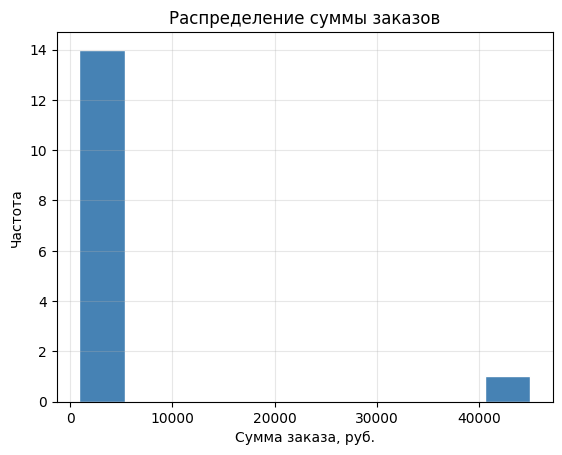

In [22]:
store_df["order_sum"].plot(kind="hist", bins=10, color="steelblue", edgecolor="white")
plt.title("Распределение суммы заказов")
plt.xlabel("Сумма заказа, руб.")
plt.ylabel("Частота")
plt.grid(alpha=0.3)
plt.show()

### Анализ распределения

Гистограмма показывает, что большинство заказов имеют сумму в диапазоне 
от 900 до 3600 рублей. Распределение сильно скошено вправо из-за одного 
экстремального значения — заказа на 45000 рублей. Этот выброс делает 
«хвост» распределения очень длинным, а основная масса данных сжата 
в левой части графика. Визуально это выглядит так, будто почти все 
заказы дешёвые, а один — аномально дорогой.

**Вывод:** наличие заказа с существенно большей суммой (45000 руб.) 
сильно искажает визуальное представление о распределении сумм заказов. 
Гистограмма становится неинформативной для основной массы данных — 
большинство столбцов «прижаты» к левому краю. Для корректного анализа 
распределения следует либо исключить выброс, либо использовать 
логарифмическую шкалу, либо строить гистограмму с ограничением по оси X 
(например, до 5000 руб.).